**Import packages and dependecies**

In [1]:
%pip install -q -e ..

Note: you may need to restart the kernel to use updated packages.


ERROR: file:///C:/Users/tcphan/OneDrive/Documents/Data%20Science%20Projects/topological does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from tda.dimensionality_reduction import UMAP

**Perform dimensionality reduction using UMAP**

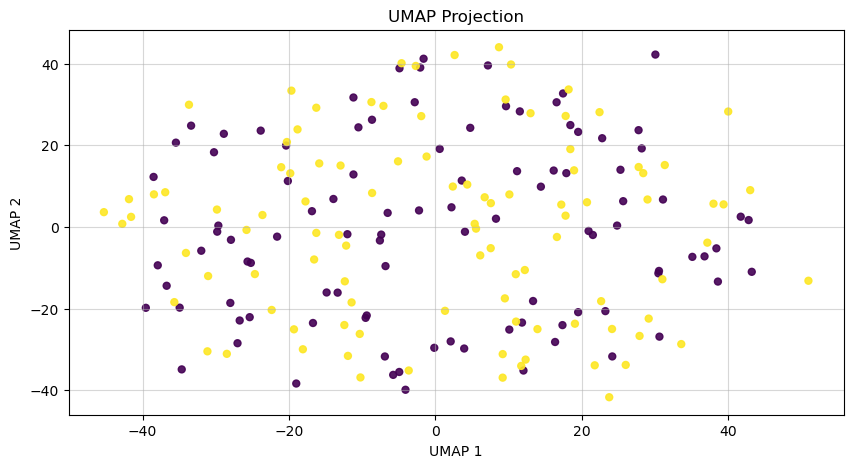

In [4]:
# Generate synthetic 3D concentric circles as sample data
rng = np.random.default_rng(42)
n_per_ring = 100

r1, r2 = 2.0, 5.0
theta = np.linspace(0, 2 * np.pi, n_per_ring)

ring1 = np.stack([r1 * np.cos(theta), r1 * np.sin(theta), rng.normal(0, 0.2, n_per_ring)], axis=1)
ring2 = np.stack([r2 * np.cos(theta), r2 * np.sin(theta), rng.normal(0, 0.2, n_per_ring)], axis=1)

df = pl.DataFrame(np.vstack([ring1, ring2]))
df = df.with_columns(labels = np.array([0] * n_per_ring + [1] * n_per_ring))

# Run UMAP
model = UMAP(n_neighbors=15, n_epochs=100, lr=1.0)
embedding = model.fit_transform(df)

umap_1 = embedding.select("umap_1").to_numpy()
umap_2 = embedding.select("umap_2").to_numpy()
labels = df.select("labels").to_numpy()

# Plot Results
plt.figure(figsize=(10, 5))
plt.scatter(umap_1, umap_2, c=labels, cmap="viridis", s=25, alpha=0.9)
plt.title("UMAP Projection")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True, linestyle="-", alpha=0.5)
plt.show()
